In [134]:
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits

In [135]:
#%% load dataset 
ds= load_digits()
data= ds['data']
target= ds['target']
print(data.shape,target.shape)

(1797, 64) (1797,)


In [136]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                                 train_size=0.7,
                                                 shuffle=True)

In [137]:
# standardize
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xtest= scaler.transform(Xtest)

In [138]:
#%% convert to tensor
Xtrain= torch.from_numpy(Xtrain).type(torch.float32).unsqueeze(2)
y_train= torch.from_numpy(y_train).type(torch.float32)
y_train_onhot=(y_train.reshape(-1,1)==
               torch.arange(10).reshape(1,-1)).type(torch.float32)



Xtest= torch.from_numpy(Xtest).type(torch.float32).unsqueeze(2)
y_test= torch.from_numpy(y_test).type(torch.float32)
y_test_onhot=(y_test.reshape(-1,1)==torch.arange(10).reshape(1,-1)).type(torch.float32)

In [139]:
class Customdataset(Dataset):
    def __init__(self,data,label):
        super().__init__()
        self.data= data
        self.label= label
    def __len__(self):
        return self.label.shape[0]
    def __getitem__(self, index):
        x= self.data[index]
        y= self.label[index]
        
        x= x.reshape(8,8)
        # x= x.permute(1,0)
        # x= x.reshape(64,1)
        return x,y
        

In [140]:
#% build data loader 
# ds= TensorDataset(Xtrain,y_train_onhot)
ds= Customdataset(Xtrain,y_train_onhot)
train_loader= DataLoader(ds,batch_size=32,
                         shuffle=False,
                         drop_last=True)

In [141]:
# y_train_onhot

In [142]:
# x,y = ds[1]
# plt.imshow(x,cmap='gray')
# plt.title(torch.argmax(y))
# plt.show()

In [143]:
def xavier_init(shape):
    fan_in, fan_out = shape[1], shape[0]
    # limit = torch.sqrt(torch.tensor(6.0 / (fan_in + fan_out)))
    # w= torch.empty(shape).uniform_(-limit, limit)
    sigma= torch.sqrt(torch.tensor(2 / (fan_in + fan_out)))
    w= torch.randn(shape)*sigma
    return w
def orthogonal_init(shape):
    # shape = (n_hidden, n_hidden)
    W = torch.randn(shape)
    q, r = torch.linalg.qr(W)
    # Ensure determinant is positive (for orthogonal)
    if torch.det(q) < 0:
        q[:, 0] = -q[:, 0]
    return q

class LSTMManual():
    def __init__(self, n_features, n_hidden, n_out, 
                 lr=0.001):
        # dims
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_out = n_out
        self.lr = lr

        # Input-to-gate weights (W), shape (n_hidden, n_features)
        self.Wf = xavier_init((n_hidden, n_features) )
        self.Wi = xavier_init((n_hidden, n_features) )
        self.Wg = xavier_init((n_hidden, n_features) )
        self.Wo = xavier_init((n_hidden, n_features)) 
        # Hidden-to-gate weights (U), shape (n_hidden, n_hidden)
        self.Uf = orthogonal_init((n_hidden, n_hidden))
        self.Ui = orthogonal_init((n_hidden, n_hidden))
        self.Ug = orthogonal_init((n_hidden, n_hidden)) 
        self.Uo = orthogonal_init((n_hidden, n_hidden)) 

        # biases (n_hidden, 1)
        self.bf = torch.zeros(n_hidden, 1)
        self.bi = torch.zeros(n_hidden, 1) 
        self.bg = torch.zeros(n_hidden, 1)
        self.bo = torch.zeros(n_hidden, 1) 

        # Output layer parameters (n_out, n_hidden)
        self.wy = xavier_init((n_out, n_hidden) )
        self.by = xavier_init((n_out, 1))

        # Grad accumulators (same shapes)
        self.dWf = torch.zeros_like(self.Wf)
        self.dWi = torch.zeros_like(self.Wi)
        self.dWg = torch.zeros_like(self.Wg)
        self.dWo = torch.zeros_like(self.Wo)

        self.dUf = torch.zeros_like(self.Uf)
        self.dUi = torch.zeros_like(self.Ui)
        self.dUg = torch.zeros_like(self.Ug)
        self.dUo = torch.zeros_like(self.Uo)

        self.dbf = torch.zeros_like(self.bf)
        self.dbi = torch.zeros_like(self.bi)
        self.dbg = torch.zeros_like(self.bg)
        self.dbo = torch.zeros_like(self.bo)

        self.dwy = torch.zeros_like(self.wy)
        self.dby = torch.zeros_like(self.by)

    # --- call/forward API similar to your RNN ---
    def __call__(self, x, h0=None, c0=None):
        return self.forward(x, h0, c0)

    def forward(self, x, h0=None, c0=None):
        batch_size, T, _ = x.size()
        n_h = self.n_hidden

        # initialize
        if h0 is None:
            h_prev = torch.zeros(n_h, batch_size)
        else:
            h_prev = h0  # assumed shape (n_hidden, batch_size)
        if c0 is None:
            c_prev = torch.zeros(n_h, batch_size)
        else:
            c_prev = c0

        yos = []
        # hts = []
        # We'll save per-timestep values needed for backprop
        saved = {
            "x": [],       # xt (n_features, batch)
            "h_prev": [],  # h_{t-1}
            "c_prev": [],  # c_{t-1}
            "f": [], "i": [], "g": [], "o": [], "c": [], "h": []
        }

        for t in range(T):
            xt = x[:, t, :].T   # (n_f, b_s)
            # gate pre-activations and activations
            zf = self.Wf @ xt + self.Uf @ h_prev + self.bf   # (n_h, b_s)
            zi = self.Wi @ xt + self.Ui @ h_prev + self.bi
            zg = self.Wg @ xt + self.Ug @ h_prev + self.bg
            zo = self.Wo @ xt + self.Uo @ h_prev + self.bo

            f_t = torch.sigmoid(zf)# (n_h, b_s)
            i_t = torch.sigmoid(zi)
            g_t = torch.tanh(zg)
            o_t = torch.sigmoid(zo)

            c_t = f_t * c_prev + i_t * g_t # (n_h, b_s)
            tanh_c_t = torch.tanh(c_t) # (n_h, b_s)
            h_t = o_t * tanh_c_t # (n_h, b_s)
            
            # hts.append(h_t)
            # saved["x"].append(xt)
            saved["h_prev"].append(h_prev)
            saved["c_prev"].append(c_prev)
            saved["f"].append(f_t)
            saved["i"].append(i_t)
            saved["g"].append(g_t)
            saved["o"].append(o_t)
            saved["c"].append(c_t)
            saved["h"].append(h_t)

            # step
            h_prev = h_t
            c_prev = c_t
            
        # output (softmax over dim=0 to match your RNN behavior)
        vout = self.wy @ h_t + self.by           # (n_out, b_size)
        y_t = torch.softmax(vout, dim=0)
        # save
        yos.append(y_t)
        return yos,saved

    # --- Backprop through time (manual) ---
    def backward(self, x, y_true, y_pred_list, saved):
        # x= saved['x'] 
        h_prev_list= saved["h_prev"] 
        c_prev_list= saved["c_prev"]
        f= saved["f"]
        i= saved["i"]
        g= saved["g"]
        o= saved["o"]
        c= saved["c"]
        h= saved["h"]
        
        n_hidden= self.n_hidden
        b_size,T,_= x.size()
        
        y_T= y_pred_list[-1] # n_out x b_s 
        d_T=  y_true.T# n_out x b_s 
        
        delta_o= d_T-y_T # n_out x b_s 
        self.dwy= delta_o@ h[-1].T # n_out x b_s 
        self.dby= torch.sum(delta_o,dim=1,keepdim=True)# n_out x 1
        
        dh_next= torch.zeros(b_size,n_hidden)
        dc_next= torch.zeros(b_size,n_hidden)
        for t in reversed(range(T)):
            xt= x[:,t,:]#  b_s * n_f
            ft= f[t].T # (n_h, b_s)
            it= i[t].T
            ot= o[t].T
            gt= g[t].T
            ct= c[t].T
            c_prev=c_prev_list[t].T
            h_prev=h_prev_list[t].T
            
            # dh from output and next step
            if t==T-1:
                dht = delta_o.T @ self.wy
            else:
                dht =   dh_next  # 
            
            dct = dht * ot * (1 - torch.tanh(ct)**2)+ dc_next  # 
            
            # b_s x n_h
            dft= dct * (c_prev)
            dit= dct* (gt)
            dot= dht* (torch.tanh(ct))
            dgt= dct * (it)

            dzf= (dft * (ft*(1-ft))).T
            dzi= (dit * (it*(1-it))).T
            dzo= (dot * (ot*(1-ot))).T
            dzg= (dgt * ((1-gt.pow(2)))).T
            
            
            self.dWf+= dzf @ xt
            self.dWi+= dzi @ xt
            self.dWo+= dzo @ xt
            self.dWg+= dzg @ xt
            
            self.dUf+= dzf @ h_prev
            self.dUi+= dzi @ h_prev
            self.dUo+= dzo @ h_prev
            self.dUg+= dzg @ h_prev
            
            
            self.dbf += torch.sum(dzf, dim=1, keepdims=True)
            self.dbi += torch.sum(dzi, dim=1, keepdims=True)
            self.dbo += torch.sum(dzo, dim=1, keepdims=True)
            self.dbg += torch.sum(dzg, dim=1, keepdims=True)
            
            dh_next =( dzf.T @ self.Uf) + (dzi.T @ self.Ui) +\
                     (dzo.T @ self.Uo) + (dzg.T @ self.Ug)

            dc_next = dct * ft
        
        # self.dWf/=(b_size*T)
        # self.dWi/=b_size
        # self.dWg/=b_size
        # self.dWo/=b_size

        # self.dUf/=b_size
        # self.dUi/=b_size
        # self.dUg/=b_size
        # self.dUo/=b_size

        # self.dbf/=b_size
        # self.dbi/=b_size
        # self.dbg/=b_size
        # self.dbo/=b_size

        # self.dwy/=b_size
        # self.dby/=b_size
              
    # reset grads
    def zero_grad(self):
        self.dWf.zero_()
        self.dWi.zero_()
        self.dWg.zero_()
        self.dWo.zero_()

        self.dUf.zero_()
        self.dUi.zero_()
        self.dUg.zero_()
        self.dUo.zero_()

        self.dbf.zero_()
        self.dbi.zero_()
        self.dbg.zero_()
        self.dbo.zero_()

        self.dwy.zero_()
        self.dby.zero_()
        
    def clipping(self,grad_clip_val):
          params= [self.dWf,self.dWi,self.dWg,self.dWo,
            self.dUf,self.dUi,self.dUg,self.dUo,
            self.dbf,self.dbi,self.dbg,self.dbo,
            self.dwy,self.dby]
          norm = torch.sqrt(sum(torch.sum((p ** 2)) for p in params))
          if norm > grad_clip_val:
               for param in params:
                    param.mul_(grad_clip_val / norm) 

    # SGD-like step (add gradients scaled by lr)
    def step(self):
        self.Wf += self.lr * self.dWf
        self.Wi += self.lr * self.dWi
        self.Wg += self.lr * self.dWg
        self.Wo += self.lr * self.dWo

        self.Uf += self.lr * self.dUf
        self.Ui += self.lr * self.dUi
        self.Ug += self.lr * self.dUg
        self.Uo += self.lr * self.dUo

        self.bf += self.lr * self.dbf
        self.bi += self.lr * self.dbi
        self.bg += self.lr * self.dbg
        self.bo += self.lr * self.dbo

        self.wy += self.lr * self.dwy
        self.by += self.lr * self.dby

    def mse(self, y_true, y_pred):
        # y_true: (batch, n_out), y_pred: list of outputs (n_out, batch)
        y_true_T = y_true.T
        y_pred_last = y_pred[-1]
        e = y_true_T - y_pred_last
        return torch.mean(e ** 2)
     
    def g_tanh(self,y):
        return (1-y**2)

    def g_sigmoid(self,y):
        return y*(1-y)

    def g_relu(self,y):
        yhat= (y>0).type(torch.float32)
        return yhat

    def g_linear(self,y):
        return torch.ones(y.size())


In [144]:
#%% train Neural Network
torch.manual_seed(1)
lr=0.1
n_out= 10
n_hid1= 128

n_features=8
mdl = LSTMManual(n_features, 
                 n_hid1, n_out, 
                 lr)

In [145]:
mse=[]
epoch=20
h0=None
c0= None
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          # farward pass
          ypred_list, saved = mdl.forward(xbatch,h0,c0)
          h0= saved['h'][-1]
          c0= saved['c'][-1]
          loss = mdl.mse(ybatch, ypred_list)
          mdl.backward(xbatch, ybatch, ypred_list, saved)
          # mdl.clipping(1)
          mdl.step()
          mdl.zero_grad()
          er.append(loss)

     loss= torch.mean(torch.tensor(er))
     mse.append(loss)
     print(f'MSE({iter}): {mse[iter]}')

mse=torch.tensor(mse)


MSE(0): 0.04421326890587807
MSE(1): 0.012944727204740047
MSE(2): 0.00624273344874382
MSE(3): 0.002040422987192869
MSE(4): 0.0006476264679804444
MSE(5): 9.945355850504711e-05
MSE(6): 7.777630344207864e-06
MSE(7): 3.576588824216742e-06
MSE(8): 2.2518458990816725e-06
MSE(9): 1.5567115951853339e-06
MSE(10): 1.1398226433811942e-06
MSE(11): 8.691643529346038e-07
MSE(12): 6.833515158177761e-07
MSE(13): 5.503083002622589e-07
MSE(14): 4.518535376973887e-07
MSE(15): 3.770157093185844e-07
MSE(16): 3.188621633398725e-07
MSE(17): 2.728201877744141e-07
MSE(18): 2.3578223817821709e-07
MSE(19): 2.0557061475301452e-07


C:\Users\Cherloo\AppData\Local\Temp\ipykernel_17416\3418317528.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse=torch.tensor(mse)


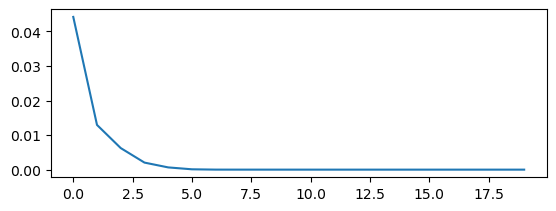

In [146]:
mse=torch.tensor(mse)
plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

In [147]:
#%% test trained Neural Network
ds_test= Customdataset(Xtest,y_test)
ypred=[]
h0=None
c0=None
for i in range(Xtest.size(0)):
    xt= ds_test[i][0]
    xt= xt.unsqueeze(0)
    # yp= mdl(xt)[0]
    ypred_list, saved = mdl.forward(xt,h0,c0)
    h0= saved['h'][-1]
    c0= saved['c'][-1]
    yp=ypred_list[-1]
    yp= torch.argmax(yp.T,dim=1)
    ypred.append(yp)

ypred= np.array(ypred)

In [148]:
ypred.shape

(540, 1)

In [149]:
ypred=ypred.flatten()
d_test= y_test.flatten()

print(ypred.shape,d_test.shape,Xtest.shape,yp[-1].shape,Xtest[i].shape)

(540,) torch.Size([540]) torch.Size([540, 64, 1]) torch.Size([]) torch.Size([64, 1])


Total accuracy:96.852%
accuracy0:100.000%
accuracy1:92.982%
accuracy2:100.000%
accuracy3:95.161%
accuracy4:100.000%
accuracy5:98.000%
accuracy6:100.000%
accuracy7:98.214%
accuracy8:91.071%
accuracy9:94.545%


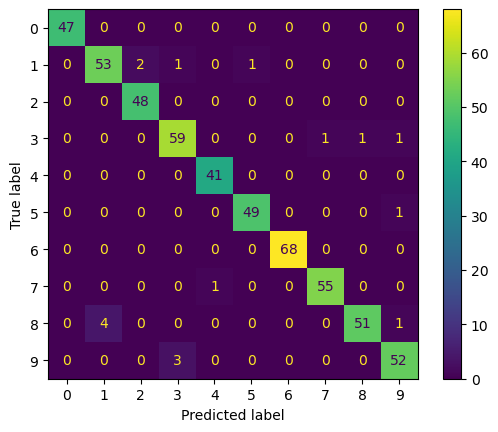

In [150]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
#%% test trained Neural Network
C= confusion_matrix(d_test,ypred)
# print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()